In [2]:
import os
print(os.getcwd())

paths = [
    "notebooks/data/processed/ri_final.parquet",
    "data/processed/ri_final.parquet",
]

for p in paths:
    print(p, os.path.exists(p))

/Users/anitanam/optical_materials_ml/notebooks
notebooks/data/processed/ri_final.parquet False
data/processed/ri_final.parquet True


In [3]:
import pandas as pd

ri_final = pd.read_parquet(
    "data/processed/ri_final.parquet"
)

ri_final.shape

(32341, 141)

In [4]:
ri_final_no_density = ri_final.drop(
    columns=["density"]
)

ri_final_no_density.shape

(32341, 140)

In [5]:
from sklearn.impute import SimpleImputer

ri_final_with_density = ri_final.copy()

imputer = SimpleImputer(
    strategy="median"
)

ri_final_with_density["density"] = (
    imputer.fit_transform(
        ri_final_with_density[["density"]]
    )
)

ri_final_with_density["density"].isna().sum()

np.int64(0)

In [6]:
ri_final_no_density.to_parquet(
    "data/processed/ri_final_no_density.parquet",
    index=False
)

ri_final_with_density.to_parquet(
    "data/processed/ri_final_with_density.parquet",
    index=False
)

In [7]:
import pandas as pd

ri_final_no_density = pd.read_parquet(
    "data/processed/ri_final_no_density.parquet"
)

ri_final_no_density.shape

(32341, 140)

In [8]:
target = "refractive_index"

X_nd = ri_final_no_density.drop(
    columns=[target]
)

y_nd = ri_final_no_density[target]

X_nd.shape, y_nd.shape

((32341, 139), (32341,))

In [9]:
X_nd = X_nd.drop(
    columns=["reduced_formula"]
)

X_nd.shape

(32341, 138)

In [10]:
from sklearn.model_selection import train_test_split

X_train_nd, X_test_nd, y_train_nd, y_test_nd = train_test_split(
    X_nd,
    y_nd,
    test_size=0.15,
    random_state=42
)

print(X_train_nd.shape)
print(X_test_nd.shape)

(27489, 138)
(4852, 138)


In [11]:
from xgboost import XGBRegressor

xgb_nd = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_nd.fit(
    X_train_nd,
    y_train_nd
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [12]:
preds_nd = xgb_nd.predict(X_test_nd)

In [13]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_nd = mean_absolute_error(
    y_test_nd,
    preds_nd
)

rmse_nd = mean_squared_error(
    y_test_nd,
    preds_nd
) ** 0.5

r2_nd = r2_score(
    y_test_nd,
    preds_nd
)

print("MAE :", mae_nd)
print("RMSE:", rmse_nd)
print("R²  :", r2_nd)

MAE : 0.02519388000554
RMSE: 0.04808167832555523
R²  : 0.9998749643052777


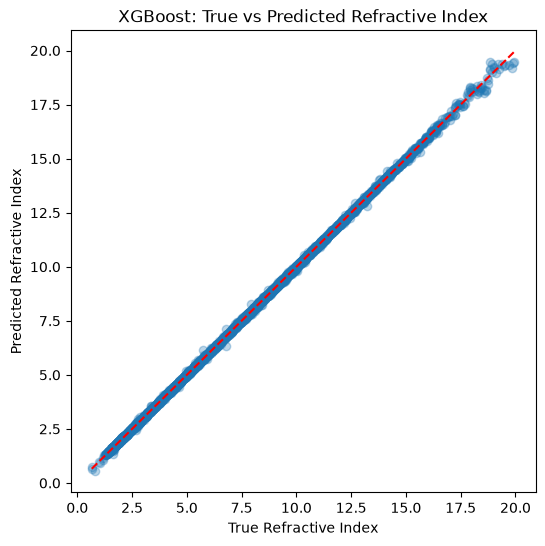

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(
    y_test_nd,
    preds_nd,
    alpha=0.3
)

plt.plot(
    [y_test_nd.min(), y_test_nd.max()],
    [y_test_nd.min(), y_test_nd.max()],
    "r--"
)

plt.xlabel("True Refractive Index")
plt.ylabel("Predicted Refractive Index")
plt.title("XGBoost: True vs Predicted Refractive Index")

plt.show()

In [15]:
feature_importance = pd.DataFrame({
    "feature": X_train_d.columns,
    "importance": xgb_d.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(20)

NameError: name 'X_train_d' is not defined

In [16]:
%who

SimpleImputer	 XGBRegressor	 X_nd	 X_test_nd	 X_train_nd	 imputer	 mae_nd	 mean_absolute_error	 mean_squared_error	 
os	 p	 paths	 pd	 plt	 preds_nd	 r2_nd	 r2_score	 ri_final	 
ri_final_no_density	 ri_final_with_density	 rmse_nd	 target	 train_test_split	 xgb_nd	 y_nd	 y_test_nd	 y_train_nd	 



In [17]:
feature_importance = pd.DataFrame({
    "feature": X_train_nd.columns,
    "importance": xgb_nd.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(20)

,feature,importance
4,epsy,0.632629
3,epsx,0.293366
5,epsz,0.068053
63,MagpieData mean NpValence,0.000691
0,optb88vdw_bandgap,0.000579
49,MagpieData maximum Electronegativity,0.000408
84,MagpieData minimum NsUnfilled,0.000280
32,MagpieData range Column,0.000252
124,MagpieData avg_dev GSbandgap,0.000166
47,MagpieData mode CovalentRadius,0.000137


In [18]:
ri_no_dielectric = ri_final_no_density.drop(
    columns=[
        "epsx",
        "epsy",
        "epsz"
    ]
)

ri_no_dielectric.shape

(32341, 137)

In [19]:
target = "refractive_index"

X = ri_no_dielectric.drop(
    columns=[target]
)

y = ri_no_dielectric[target]

In [21]:
from sklearn.model_selection import train_test_split

target = "refractive_index"

X = ri_no_dielectric.drop(columns=[target])
y = ri_no_dielectric[target]

X = X.drop(columns=["reduced_formula"])

X_train_no_diel, X_test_no_diel, y_train_no_diel, y_test_no_diel = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42
)

In [22]:
from xgboost import XGBRegressor

xgb_no_dielectric = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_no_dielectric.fit(
    X_train_no_diel,
    y_train_no_diel
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [23]:
preds_no_diel = xgb_no_dielectric.predict(
    X_test_no_diel
)

In [24]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_no_diel = mean_absolute_error(
    y_test_no_diel,
    preds_no_diel
)

rmse_no_diel = mean_squared_error(
    y_test_no_diel,
    preds_no_diel
) ** 0.5

r2_no_diel = r2_score(
    y_test_no_diel,
    preds_no_diel
)

print("MAE :", mae_no_diel)
print("RMSE:", rmse_no_diel)
print("R²  :", r2_no_diel)

MAE : 1.4518224796613244
RMSE: 2.1789543572847188
R²  : 0.743214178411984


In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# If ri_final_with_density is already in memory, use it.
# Otherwise load it from disk:
try:
    ri_final_with_density
except NameError:
    ri_final_with_density = pd.read_parquet("data/processed/ri_final_with_density.parquet")

ri_no_dielectric_density = ri_final_with_density.drop(
    columns=["epsx", "epsy", "epsz"]
).copy()

ri_no_dielectric_density.shape

(32341, 138)

In [26]:
target = "refractive_index"

X = ri_no_dielectric_density.drop(columns=[target, "reduced_formula"])
y = ri_no_dielectric_density[target]

X_train_dens, X_test_dens, y_train_dens, y_test_dens = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42
)

print(X_train_dens.shape)
print(X_test_dens.shape)

(27489, 136)
(4852, 136)


In [27]:
xgb_no_diel_density = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_no_diel_density.fit(X_train_dens, y_train_dens)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [28]:
preds_dens = xgb_no_diel_density.predict(X_test_dens)

mae_dens = mean_absolute_error(y_test_dens, preds_dens)
rmse_dens = mean_squared_error(y_test_dens, preds_dens) ** 0.5
r2_dens = r2_score(y_test_dens, preds_dens)

print("MAE :", mae_dens)
print("RMSE:", rmse_dens)
print("R²  :", r2_dens)

MAE : 1.458618155396847
RMSE: 2.182130725987367
R²  : 0.7424649741451075


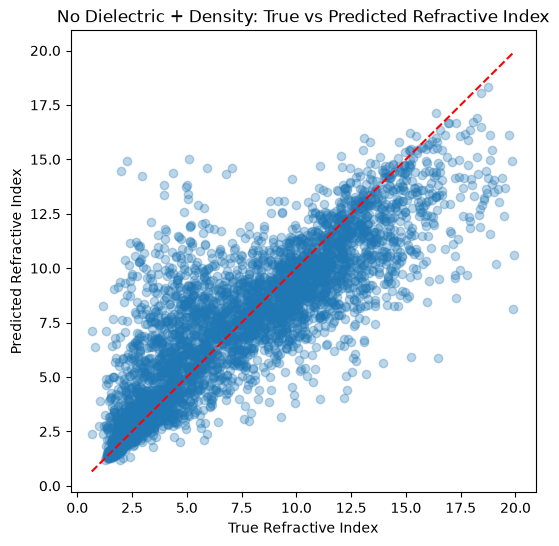

In [29]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_dens, preds_dens, alpha=0.3)
plt.plot(
    [y_test_dens.min(), y_test_dens.max()],
    [y_test_dens.min(), y_test_dens.max()],
    "r--"
)
plt.xlabel("True Refractive Index")
plt.ylabel("Predicted Refractive Index")
plt.title("No Dielectric + Density: True vs Predicted Refractive Index")
plt.show()

In [30]:
feature_importance = pd.DataFrame({
    "feature": X_train_dens.columns,
    "importance": xgb_no_diel_density.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance.head(20)

,feature,importance
0,optb88vdw_bandgap,0.103329
47,MagpieData maximum Electronegativity,0.091620
11,MagpieData maximum MendeleevNumber,0.059498
27,MagpieData mode MeltingT,0.036403
61,MagpieData mean NpValence,0.030521
135,MagpieData mode SpaceGroupNumber,0.027413
121,MagpieData mean GSbandgap,0.023335
97,MagpieData mean NdUnfilled,0.021055
99,MagpieData mode NdUnfilled,0.019532
33,MagpieData mode Column,0.017668


In [31]:
comparison = pd.DataFrame({
    "model": [
        "No dielectric",
        "No dielectric + density",
        "With dielectric tensor"
    ],
    "MAE": [
        mae_no_diel,
        mae_dens,
        mae_nd
    ],
    "RMSE": [
        rmse_no_diel,
        rmse_dens,
        rmse_nd
    ],
    "R2": [
        r2_no_diel,
        r2_dens,
        r2_nd
    ]
})

comparison

,model,MAE,RMSE,R2
0,No dielectric,1.451822,2.178954,0.743214
1,No dielectric + density,1.458618,2.182131,0.742465
2,With dielectric tensor,0.025194,0.048082,0.999875


In [32]:
comparison.sort_values(by="R2", ascending=False)

,model,MAE,RMSE,R2
2,With dielectric tensor,0.025194,0.048082,0.999875
0,No dielectric,1.451822,2.178954,0.743214
1,No dielectric + density,1.458618,2.182131,0.742465


In [33]:
comparison = pd.DataFrame({
    "Model": [
        "Full Physics (with dielectric tensor)",
        "No Dielectric Tensor",
        "No Dielectric Tensor + Density"
    ],
    "MAE": [
        0.02519,
        1.45182,
        1.45862
    ],
    "RMSE": [
        0.04808,
        2.17895,
        2.18213
    ],
    "R2": [
        0.99987,
        0.74321,
        0.74246
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Full Physics (with dielectric tensor),0.02519,0.04808,0.99987
1,No Dielectric Tensor,1.45182,2.17895,0.74321
2,No Dielectric Tensor + Density,1.45862,2.18213,0.74246


In [34]:
comparison.to_csv(
    "results/refractive_index_model_comparison.csv",
    index=False
)

In [35]:
import os
os.path.exists(
    "results/refractive_index_model_comparison.csv"
)

True